# TD10: Ejective consonants and altitude

## 0. Question

Today, we will answer the following question:

*Are languages spoken at higher altitude more likely to have ejective consonants?*

We will use phonological inventory data from PHOIBLE and an elevation table based on the coordinates of each language. The goal is to replicate the results of [Everett (2013)](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0065275) and to understand the relationship between ejective consonants and altitude.


In [36]:
# If Basemap is not installed, you can uncomment the following line. 
# IF YOU HAVE PROBLEMS INSTALLING BASEMAP, IGNORE THIS LINE.
# !pip install basemap

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

sns.set(context='notebook', style='ticks',
        font_scale=1.1, palette='colorblind')


## 1. Data

You will need to download `values.csv`, `parameters.csv` and `languages.csv` from [this Zenodo repository](https://zenodo.org/records/2677911). Then put it in the cldf forlder, which already contains the `elevation_data.csv` file.

In the `cldf` folder, you will find a CLDF version of PHOIBLE. We will use three files:

- `values.csv`: one row per segment in one language inventory
- `parameters.csv`: information about each segment, including phonological features
- `languages.csv`: language names, macroareas, and coordinates

The file `elevation_data.csv` was cached in advance from the [Open-Meteo Elevation API](https://open-meteo.com/en/docs/elevation-api), which estimates terrain elevation for latitude and longitude coordinates. 


In [37]:
BASE = Path('.')
if not (BASE / 'cldf').exists():
    BASE = Path('S10')

values = pd.read_csv(BASE / 'cldf' / 'values.csv', low_memory=False)
parameters = pd.read_csv(BASE / 'cldf' / 'parameters.csv', low_memory=False)
languages = pd.read_csv(BASE / 'cldf' / 'languages.csv')
elevation = pd.read_csv(BASE /'cldf'/ 'elevation_data.csv')

values.shape, parameters.shape, languages.shape, elevation.shape

((105466, 10), (3183, 41), (2186, 9), (2059, 6))

Let's inspect the segment lists. Each row corresponds to one segment (one phoneme, although they are encoded using IPA symbols) in one language inventory.


In [38]:
values.head(10)

,ID,Language_ID,Parameter_ID,Value,Code_ID,Comment,Source,Marginal,Allophones,Contribution_ID
0,1,kore1280,72FB536ACFF408163656BBCDAFCAC6F6,a,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,a,1
1,2,kore1280,2F272C9C5FA2DA70706B565B2DC46DE8,aː,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,aː,1
2,3,kore1280,B6D180EA250E6FBDE82C3D1F1BB4A39C,æ,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,ɛ æ,1
3,4,kore1280,CB37024CEAE9409F30FC756C0578E93C,æː,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,æː,1
4,5,kore1280,199408E3D0668F10F475143F0E8CC0CB,e,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,e,1
5,6,kore1280,6DD56E3A80E90C3B1F5AC7AC45CE8180,eː,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,eː,1
6,7,kore1280,80E0B47CF9A1F002B35B6AAB49574C61,ɤ,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,ɤ,1
7,8,kore1280,5C19A8FEDB2B0124AA7C66E689586A64,ɤː,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,ɤː,1
8,9,kore1280,E7FBD92350B3CA8B7B5D77E36A607068,h,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,ç h ɦ,1
9,10,kore1280,F0585BB57111C322D6E7DABB0D01F9EA,i,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,i,1


Now look at the language table. Which columns will we need for a geographical analysis?


In [39]:
languages.head(10)


,ID,Name,Macroarea,Latitude,Longitude,Glottocode,ISO639P3code,Family_Glottocode,Family_Name
0,kore1280,Korean,Eurasia,37.500000,128.00000,kore1280,kor,kore1284,Koreanic
1,kett1243,Ket,Eurasia,63.755100,87.54660,kett1243,ket,yeni1252,Yeniseian
2,lakk1252,Lak,Eurasia,42.132800,47.08090,lakk1252,lbe,nakh1245,Nakh-Daghestanian
3,kaba1278,Kabardian,Eurasia,43.508200,43.39180,kaba1278,kbd,abkh1242,Abkhaz-Adyge
4,nucl1302,Georgian,Eurasia,41.850397,43.78613,nucl1302,kat,kart1248,Kartvelian
5,buru1296,Burushaski,Eurasia,36.216100,74.82360,buru1296,bsk,NaN,NaN
6,kuru1302,Kurukh,Eurasia,24.464400,86.46570,kuru1302,kru,drav1251,Dravidian
7,telu1262,Telugu,Eurasia,16.452900,78.70240,telu1262,tel,drav1251,Dravidian
8,kota1263,Kota (India),Eurasia,11.497800,76.93870,kota1263,kfe,drav1251,Dravidian
9,mund1320,Mundari,Eurasia,25.039100,87.17920,mund1320,unr,aust1305,Austroasiatic


The parameter dataphrame is where we can find whether or not the segment is ejective. The relevant feature column is `raisedLarynxEjective`.


In [40]:
parameters.columns


Index(['ID', 'Name', 'Description', 'SegmentClass', 'tone', 'stress',
       'syllabic', 'short', 'long', 'consonantal', 'sonorant', 'continuant',
       'delayedRelease', 'approximant', 'tap', 'trill', 'nasal', 'lateral',
       'labial', 'round', 'labiodental', 'coronal', 'anterior', 'distributed',
       'strident', 'dorsal', 'high', 'low', 'front', 'back', 'tense',
       'retractedTongueRoot', 'advancedTongueRoot', 'periodicGlottalSource',
       'epilaryngealSource', 'spreadGlottis', 'constrictedGlottis', 'fortis',
       'raisedLarynxEjective', 'loweredLarynxImplosive', 'click'],
      dtype='object')

Let's extract the segment types that are marked as ejective. 


In [41]:
ejective_segments = parameters.query('raisedLarynxEjective == "+"')
ejective_segments[['Name', 'Description', 'SegmentClass', 'raisedLarynxEjective']].head(20)

,Name,Description,SegmentClass,raisedLarynxEjective
67,kʷʼ,LATIN SMALL LETTER K - MODIFIER LETTER SMALL W...,consonant,+
68,kʼ,LATIN SMALL LETTER K - MODIFIER LETTER APOSTROPHE,consonant,+
71,pʼ,LATIN SMALL LETTER P - MODIFIER LETTER APOSTROPHE,consonant,+
76,qʷʼ,LATIN SMALL LETTER Q - MODIFIER LETTER SMALL W...,consonant,+
77,qʼ,LATIN SMALL LETTER Q - MODIFIER LETTER APOSTROPHE,consonant,+
89,tsʷʼ,LATIN SMALL LETTER T - LATIN SMALL LETTER S - ...,consonant,+
90,tsʼ,LATIN SMALL LETTER T - LATIN SMALL LETTER S - ...,consonant,+
94,t̠ʃʷʼ,LATIN SMALL LETTER T - COMBINING MINUS SIGN BE...,consonant,+
95,t̠ʃʼ,LATIN SMALL LETTER T - COMBINING MINUS SIGN BE...,consonant,+
96,tʼ,LATIN SMALL LETTER T - MODIFIER LETTER APOSTROPHE,consonant,+


How many distinct segment types in PHOIBLE are marked as ejective?


In [42]:
##################
# YOUR CODE HERE #
##################

Now combine the segment observations with the feature table. This will let us know, for every segment observed in every language, whether that segment is an ejective consonant. Keep only the following columns in the parameters dataframe: `ID`,`Name`, `SegmentClass`, `raisedLarynxEjective`. Call the resulting dataframe `segments`.


In [43]:
##################
# YOUR CODE HERE #
##################

segments.head(10)


,ID_x,Language_ID,Parameter_ID,Value,Code_ID,Comment,Source,Marginal,Allophones,Contribution_ID,ID_y,Name,SegmentClass,raisedLarynxEjective
0,1,kore1280,72FB536ACFF408163656BBCDAFCAC6F6,a,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,a,1,72FB536ACFF408163656BBCDAFCAC6F6,a,vowel,-
1,2,kore1280,2F272C9C5FA2DA70706B565B2DC46DE8,aː,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,aː,1,2F272C9C5FA2DA70706B565B2DC46DE8,aː,vowel,-
2,3,kore1280,B6D180EA250E6FBDE82C3D1F1BB4A39C,æ,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,ɛ æ,1,B6D180EA250E6FBDE82C3D1F1BB4A39C,æ,vowel,-
3,4,kore1280,CB37024CEAE9409F30FC756C0578E93C,æː,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,æː,1,CB37024CEAE9409F30FC756C0578E93C,æː,vowel,-
4,5,kore1280,199408E3D0668F10F475143F0E8CC0CB,e,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,e,1,199408E3D0668F10F475143F0E8CC0CB,e,vowel,-
5,6,kore1280,6DD56E3A80E90C3B1F5AC7AC45CE8180,eː,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,eː,1,6DD56E3A80E90C3B1F5AC7AC45CE8180,eː,vowel,-
6,7,kore1280,80E0B47CF9A1F002B35B6AAB49574C61,ɤ,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,ɤ,1,80E0B47CF9A1F002B35B6AAB49574C61,ɤ,vowel,-
7,8,kore1280,5C19A8FEDB2B0124AA7C66E689586A64,ɤː,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,ɤː,1,5C19A8FEDB2B0124AA7C66E689586A64,ɤː,vowel,-
8,9,kore1280,E7FBD92350B3CA8B7B5D77E36A607068,h,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,ç h ɦ,1,E7FBD92350B3CA8B7B5D77E36A607068,h,consonant,-
9,10,kore1280,F0585BB57111C322D6E7DABB0D01F9EA,i,NaN,NaN,cho1967;martin1951;martin1954;martinlee1969;ki...,NaN,i,1,F0585BB57111C322D6E7DABB0D01F9EA,i,vowel,-


PHOIBLE can contain more than one inventory contribution for the same language. Today, we will count each segment type only once per language. The code below removes duplicate inventory contributions for the same language, keeping only the first one.


In [9]:
# Keep only one inventory contribution per language (choose the smallest Contribution_ID)
one_contrib_per_lang = segments.groupby('Language_ID')['Contribution_ID'].min()

segments_unique = segments[
    segments['Contribution_ID'].eq(segments['Language_ID'].map(one_contrib_per_lang))
].copy()

# Safety: keep each segment type only once per language
segments_unique = segments_unique.drop_duplicates(['Language_ID', 'Parameter_ID'])

segments.shape, segments_unique.shape

((105466, 14), (75511, 14))

Create the `is_ejective` column, which is `True` if the segment is an ejective consonant and `False` otherwise. Also create the `is_consonant` column, which is `True` if the segment is a consonant and `False` otherwise.

In [ ]:
##################
# YOUR CODE HERE #
##################

segments_unique[['Language_ID', 'Value', 'Name', 'SegmentClass', 'is_ejective']].head(10)


,Language_ID,Value,Name,SegmentClass,is_ejective
0,kore1280,a,a,vowel,False
1,kore1280,aː,aː,vowel,False
2,kore1280,æ,æ,vowel,False
3,kore1280,æː,æː,vowel,False
4,kore1280,e,e,vowel,False
5,kore1280,eː,eː,vowel,False
6,kore1280,ɤ,ɤ,vowel,False
7,kore1280,ɤː,ɤː,vowel,False
8,kore1280,h,h,consonant,False
9,kore1280,i,i,vowel,False


Now we can move from segment-level data to language-level data. For each language, count the total number of distinct segments, the number of consonants, and the number of ejectives. Use the `groupby` method to group by `Language_ID`, and then use the `agg` method to count the number of segments, consonants, and ejectives. Call the resulting dataframe `lang_ejectives`.


In [ ]:
##################
# YOUR CODE HERE #
##################


,Language_ID,n_segments,n_consonants,n_ejectives,has_ejective,has_ejective_int
0,aari1239,36,26,2,True,1
1,abar1238,36,24,0,False,0
2,abau1245,14,9,0,False,0
3,abid1235,39,21,0,False,0
4,abip1241,20,15,0,False,0
5,abis1238,27,17,0,False,0
6,abkh1244,62,59,13,True,1
7,abua1244,40,27,0,False,0
8,abuj1237,39,22,0,False,0
9,abur1243,38,20,0,False,0


Add a binary column `has_ejective` that is `True` if the language has at least one ejective consonant and `False` otherwise. Also add a column `has_ejective_int` that is `1` if the language has at least one ejective consonant and `0` otherwise. We will use this column for the correlation analysis later on.

In [ ]:
##################
# YOUR CODE HERE #
##################

Which languages have the largest number of ejective segment types in this dataset?


In [18]:
lang_ejectives.sort_values('n_ejectives', ascending=False).head(15)

,Language_ID,n_segments,n_consonants,n_ejectives,has_ejective,has_ejective_int
684,huaa1248,161,130,21,True,1
110,arch1244,91,81,15,True,1
372,coeu1236,48,40,14,True,1
1877,tlin1245,48,43,14,True,1
24,adyg1241,59,56,13,True,1
6,abkh1244,62,59,13,True,1
2185,zuni1245,54,44,12,True,1
1628,rutu1240,64,59,12,True,1
815,kamb1316,59,49,12,True,1
75,andi1255,68,63,11,True,1


Do you find this number to be plausible? Why or why not? Can you find out more about this language?

Next, add language names, macroareas, coordinates, and elevation. You would need to merge the `lang_ejectives` dataframe with the `languages_small` and `elevation_data` dataframes. The `Language_ID` column is the key for merging with the `languages` dataframe, and the `Language_ID` column is also the key for merging with the `elevation_data` dataframe. Save this merged dataframe as `f`.


In [ ]:
languages_small = languages[['ID', 'Name', 'Macroarea', 'Latitude', 'Longitude', 'Family_Name']]

##################
# YOUR CODE HERE #
##################


Missing elevations: 135


(2051, 14)

Now drop rows without an elevation estimate, and convert them to kilometers by dividing by 1000. How many languages do we have in the final dataset?

In [ ]:
f['elevation_m'] = pd.to_numeric(f['elevation_m'], errors='coerce')
print('Missing elevations:', f['elevation_m'].isna().sum())

##################
# YOUR CODE HERE #
##################

Missing elevations: 135


(2051, 14)

Let's look at the results:

In [22]:
df.head(10)


,Language_ID,n_segments,n_consonants,n_ejectives,has_ejective,has_ejective_int,ID,Name,Macroarea,Latitude,Longitude,Family_Name,elevation_m,elevation_km
0,aari1239,36,26,2,True,1,aari1239,Aari,Africa,5.950340,36.572100,South Omotic,1506.0,1.506
1,abar1238,36,24,0,False,0,abar1238,Mungbam,Africa,6.580500,10.226700,Atlantic-Congo,720.0,0.720
2,abau1245,14,9,0,False,0,abau1245,Abau,Papunesia,-3.972220,141.324000,Sepik,54.0,0.054
3,abid1235,39,21,0,False,0,abid1235,Abidji,Africa,5.656560,-4.584210,Atlantic-Congo,93.0,0.093
4,abip1241,20,15,0,False,0,abip1241,Abipon,South America,-29.000000,-61.000000,Guaicuruan,55.0,0.055
5,abis1238,27,17,0,False,0,abis1238,Aewa,South America,-0.693860,-75.218300,NaN,233.0,0.233
6,abkh1244,62,59,13,True,1,abkh1244,Abkhazian,Eurasia,43.056218,41.159115,Abkhaz-Adyge,601.0,0.601
7,abua1244,40,27,0,False,0,abua1244,Abua,Africa,4.830570,6.614920,Atlantic-Congo,11.0,0.011
9,abur1243,38,20,0,False,0,abur1243,Abure,Africa,5.215340,-3.641230,Atlantic-Congo,4.0,0.004
10,acat1239,30,20,0,False,0,acat1239,Acatepec Me'phaa,North America,17.103400,-99.060200,Otomanguean,615.0,0.615


Before modeling anything, check the outcome variable. What proportion of languages in this dataset have at least one ejective consonant?


In [ ]:
##################
# YOUR CODE HERE #
##################

has_ejective
False    0.916626
True     0.083374
Name: proportion, dtype: float64

## 2. Exploratory analysis

Let's first look at the elevation variable itself. Do the minimum and maximum values look plausible?


In [24]:
df['elevation_m'].describe()


count    2051.000000
mean      644.702097
std       837.474116
min        -6.000000
25%       125.000000
50%       322.000000
75%       843.500000
max      5588.000000
Name: elevation_m, dtype: float64

Which languages in the sample have the highest estimated elevation? Do they all have ejectives?


In [ ]:
##################
# YOUR CODE HERE #
##################

,Name,Macroarea,elevation_m,n_ejectives,has_ejective
170,Balti,Eurasia,5588.0,0,False
1761,Spiti Bhoti,Eurasia,5501.0,0,False
1860,Tibetan,Eurasia,5395.0,0,False
997,Leh-Kenhat,Eurasia,5198.0,0,False
1596,Purik-Sham-Nubra,Eurasia,5052.0,0,False
1709,Sikkimese,Eurasia,4992.0,0,False
694,Humla,Eurasia,4877.0,0,False
1698,Shixing,Eurasia,4788.0,0,False
761,Jauja Wanca Quechua,South America,4733.0,0,False
1693,Solu-Khumbu Sherpa,Eurasia,4624.0,0,False


Now compare the elevation distributions for languages with and without ejectives.


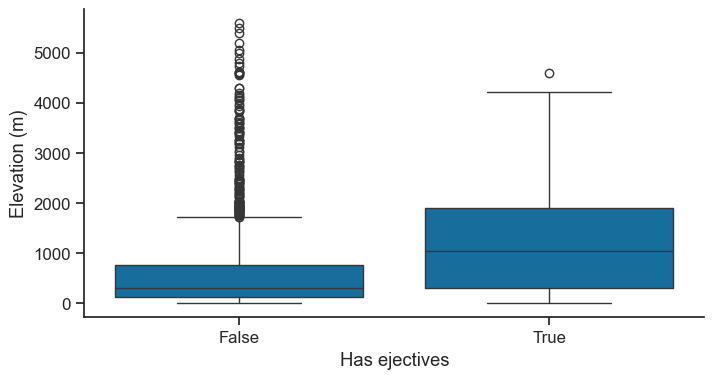

In [ ]:
##################
# YOUR CODE HERE #
##################

Perform a two-sample t-test. Are languages with ejectives spoken at higher estimated elevations than languages without ejectives?


In [ ]:
##################
# YOUR CODE HERE #
##################

TtestResult(statistic=7.714006168083455, pvalue=6.5208752623849e-13, df=191.4367707046557)

## 3. Logistic regression

A simple way to model a binary outcome is logistic regression. Here, the outcome is whether a language has at least one ejective consonant. The predictor is elevation in kilometers. Use the `smf.logit` function from the statsmodels library to fit a logistic regression model. What is the effect of elevation on the probability of having ejectives? Is it significant?


In [ ]:
##################
# YOUR CODE HERE #
##################

Convert the coefficient into an odds ratio. This tells us how the odds of having an ejective change for each additional kilometer of elevation.


In [31]:
odds_ratio = np.exp(model.params['elevation_km'])
print(f'Estimated odds ratio for a 1 km increase: {odds_ratio:.2f}')


Estimated odds ratio for a 1 km increase: 1.75


Plot the results of the regression using the `regplot` function from seaborn. You can read about it [here](https://seaborn.pydata.org/generated/seaborn.regplot.html). 

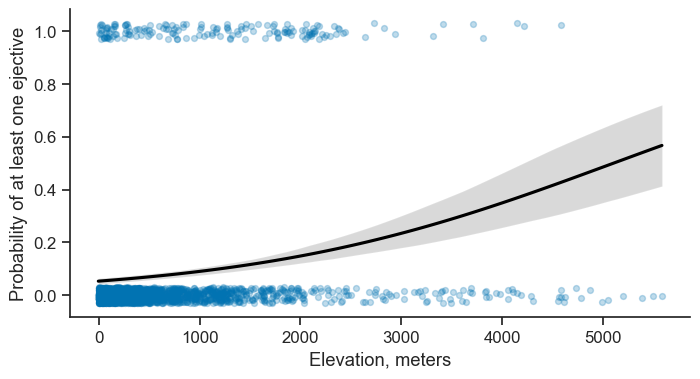

In [ ]:
plt.figure(figsize=(8, 4))
sns.regplot(
    data=df,
    x='elevation_m',
    y='has_ejective_int',
    logistic=True,
    y_jitter=0.03,
    scatter_kws={'alpha': 0.25, 's': 18},
    line_kws={'color': 'black'}
)
plt.xlabel('Elevation, meters')
plt.ylabel('Probability of at least one ejective')
sns.despine()
plt.show()


## 4. A first look at confounding

Languages are not independent points scattered randomly around the globe. Before trusting the altitude effect too much, let's check whether ejectives are concentrated in particular macroareas.


In [32]:
macroarea_summary = (
    df.groupby('Macroarea')['has_ejective']
    .agg(probability='mean', n_ejectives='sum', n_languages='count')
    .sort_values('probability', ascending=False)
)

macroarea_summary


,probability,n_ejectives,n_languages
Macroarea,,,
North America,0.433566,62,143
Africa,0.085014,59,694
South America,0.069909,23,329
Eurasia,0.060890,26,427
Papunesia,0.005376,1,186
Australia,0.000000,0,272


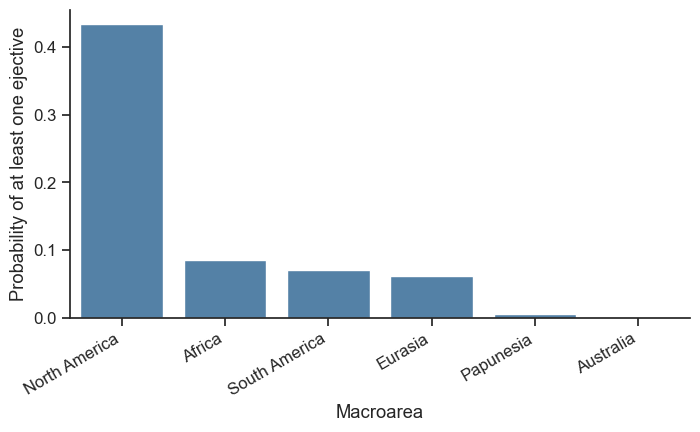

In [33]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=macroarea_summary.reset_index(),
    x='Macroarea',
    y='probability',
    color='steelblue'
)
plt.xlabel('Macroarea')
plt.ylabel('Probability of at least one ejective')
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.show()


As an optional extension, fit a model that includes macroarea. In this sample, Australia and Papunesia have no or almost no languages with ejectives, which makes the logistic model unstable, so we will remove them from our sample. 

Run the new model, adding another categorical predictor for macroarea using the `C()` function from statsmodels. How does the altitude effect change when we control for macroarea?

In [ ]:
##################
# YOUR CODE HERE #
##################

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       has_ejective_int   No. Observations:                 1593
Model:                          Logit   Df Residuals:                     1588
Method:                           MLE   Df Model:                            4
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                  0.1570
Time:                        13:41:38   Log-Likelihood:                -456.07
converged:                       True   LL-Null:                       -540.98
Covariance Type:            nonrobust   LLR p-value:                 1.147e-35
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -2.8279      0.153    -18.439      0.000      -3.129      -2.527
C(Macroarea)[T.Eurasia]          -0.8237      0.271     -3.038      0.002      -1.355      -0.292
C(Macroarea)[T.North America]     2.0735      0.221      9.396      0.000       1.641       2.506
C(Macroarea)[T.South America]    -0.2669      0.263     -1.014      0.311      -0.783       0.249
elevation_km                      0.6045      0.082      7.370      0.000       0.444       0.765
=================================================================================================
"""

What can you tell about the relationship between ejectives and altitude after controlling for macroarea? Does this change your interpretation of the results?

Finally, make a map. Are the ejective languages spread evenly across the world, or do they cluster  geographically? You can take inspiration from the map we made in [TD8](https://github.com/alexeykosh/intro-to-ling-2026/blob/main/s8/TD8_clics_database_solutions.ipynb).


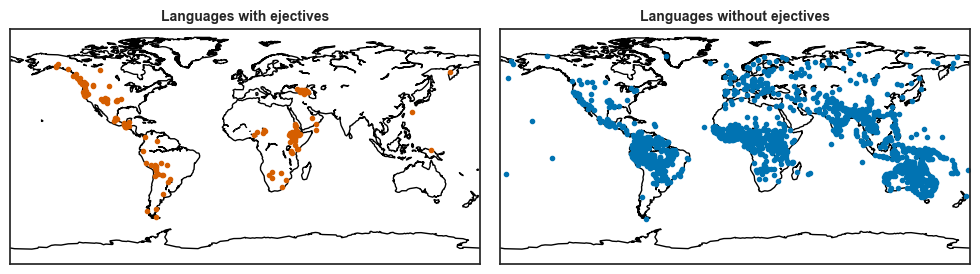

In [ ]:
##################
# YOUR CODE HERE #
##################